# Predict Loan Default
## Question: Can we predict if a person will default on their loan?


Read the data from the CSV file. 

In [6]:
import pandas as pd

df = pd.read_csv("data/credit_risk_dataset.csv")
df_raw = df.copy()  # Keep raw data just in case 
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.describe() #see what data we have
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


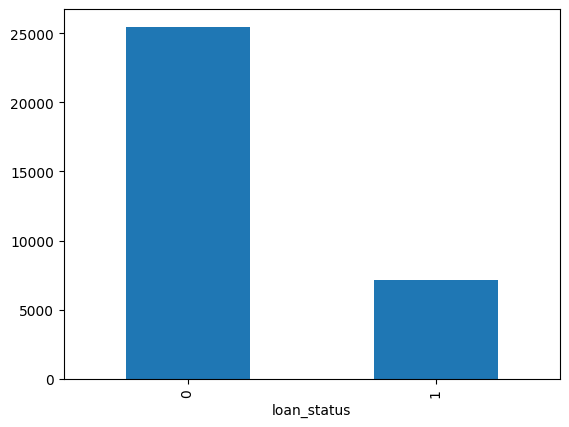

In [8]:
import matplotlib.pyplot as plt
df['loan_status'].value_counts() #target variable to explore 
df['loan_status'].value_counts().plot(kind='bar') #show the bar chart of loan_status 
plt.show()

See if any missing data and do some data cleaning. 

In [9]:
print("The raw data without any modifications: ")
print(df_raw.isna().sum()) #see what data is missing

# person_emp_length and load_int_rate are the only two columns that have missing values. 
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median()) #fill in missing values using the median of the entire dataset 
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median()) #fill in missing values using the median of the entire dataset

print("\nData after filling missing values: ")
print(df.isna().sum()) #see it correctly filled in the data 

The raw data without any modifications: 
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Data after filling missing values: 
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


Set the target variable and the predictor variables. 

In [10]:
y = df['loan_status'] # target variable
X = pd.get_dummies(df.drop(columns=['loan_status']), drop_first=True) # one one encoding 

print(X.shape)


(32581, 22)


Split the data into train and test sets. 

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(26064, 22)
(6517, 22)
(26064,)
(6517,)


# Model 1: Logistic Regression
## Try standardization - scaling transformation

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Try Polynomial Feature Transformation degree = 2


In [13]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features up to degree 2 (includes squares, interactions)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

## Try PCA Feature Transformation 


In [14]:
from sklearn.decomposition import PCA

# Reduce to top N components (say, 10)
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## Try Interaction-only Features 


In [15]:
poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_inter = poly_interact.fit_transform(X_train_scaled)
X_test_inter = poly_interact.transform(X_test_scaled)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = [] # a list to store the results

#loop through the values of C and fit a logistic regression model on the training set 
def model_evaluation(X_train_t, X_test_t, y_train, y_test, transform_name):

    for val in C_values:
        
        model = LogisticRegression(C = val, max_iter=1000)
        model.fit(X_train_t, y_train)
        y_pred = model.predict(X_test_t)
        
        
        results.append({
            'Transformation': transform_name,
            'regularization parameter C': val,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1 Score': f1_score(y_test, y_pred)
        })
        
model_evaluation(X_train_scaled, X_test_scaled, y_train, y_test, 'Original')
model_evaluation(X_train_poly, X_test_poly, y_train, y_test, 'Polynomial')
model_evaluation(X_train_pca, X_test_pca, y_train, y_test, 'PCA')
model_evaluation(X_train_inter, X_test_inter, y_train, y_test, 'Interaction Only')


In [18]:
results_df = pd.DataFrame(results)
results_df.head(24)
# results_df.tail(1)
# print(results_df)

,Transformation,regularization parameter C,Accuracy,Precision,Recall,F1 Score
0,Original,0.001,0.851772,0.799750,0.442215,0.569519
1,Original,0.010,0.862667,0.773904,0.537716,0.634545
2,Original,0.100,0.862207,0.766310,0.544637,0.636731
3,Original,1.000,0.861900,0.764820,0.544637,0.636217
4,Original,10.000,0.861900,0.764820,0.544637,0.636217
5,Original,100.000,0.861900,0.764820,0.544637,0.636217
6,Polynomial,0.001,0.895351,0.890481,0.602076,0.718415
7,Polynomial,0.010,0.900414,0.869888,0.647751,0.742562
8,Polynomial,0.100,0.902409,0.868733,0.659516,0.749803
9,Polynomial,1.000,0.902563,0.866184,0.662976,0.751078


# Model 2: Support Vector Machines

# Model 3: Neural Networks

Use the neural network model from the sklearn package to train the data.   

MLPClassifier uses "ReLU" as an activation function.   

For binary classification, the final layer uses the logistic (sigmoid) activation. 


### Preliminary Stage: Testing the code & Figure out how it works

In [19]:
# Import Multi-Layer Perceptron
from sklearn.neural_network import MLPClassifier

# Create a Multi-Layer Perceptron model
# with one hidden layer of 100 neurons
# and a maximum of 300 iterations

model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

hidden_layer_sizes=(64, 32)  # 2 layers: 64 neurons, then 32 neurons

In [20]:
# Takes test inputs (X_test_scaled)
# Runs them through the trained neural network
# Outputs predictions (0 = no default, 1 = default)

y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9139174466779193
Precision: 0.8843478260869565
Recall: 0.7038062283737024
F1 Score: 0.7838150289017342


## Train Neural Networks with Original Features
Uses different hidden sizes of neurons to train the model.  
As well as, uses different iteration numbers to see the results. 

### Actual Training Stage

In [22]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Hide convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [23]:
hidden_sizes = [(50,), #hidden layer of 50 neurons
                (100,), #hidden layer of 100 neurons
                (64, 32), #hidden layer of 64 neurons and 32 neurons (2 layers)
                (128, 64), #hidden layer of 128 neurons and 64 neurons (2 layers)
                (32, 32, 16)] #hidden layer of 32 neurons, 32 neurons, and 16 neurons (3 layers)
results = []
iteration = [300, 500, 1000] #number of iterations to train the model
activations = ['relu', 'tanh', 'logistic'] # activation functions to use
for alpha in C_values: # loop through the regularization parameters
    for activation in activations: # loop through the activation functions
        for size in hidden_sizes: # loop through the hidden layer sizes
            for it in iteration: # loop through the number of iterations (different architectures)
                model = MLPClassifier(hidden_layer_sizes=size, max_iter=it, random_state=42, activation=activation, alpha=alpha)
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)

                results.append({
                    'Activation': activation,
                    'Architecture': str(size),
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, zero_division=1),
                    'Recall': recall_score(y_test, y_pred),
                    'F1 Score': f1_score(y_test, y_pred)
                })

In [25]:
df_nn_results = pd.DataFrame(results)
print("Neural Network Results (Original Features):")
print(df_nn_results)

Neural Network Results (Original Features):
    Activation  Architecture  Accuracy  Precision    Recall  F1 Score
0         relu         (50,)  0.917907   0.913636  0.695502  0.789784
1         relu         (50,)  0.919902   0.929302  0.691349  0.792857
2         relu         (50,)  0.919902   0.929302  0.691349  0.792857
3         relu        (100,)  0.916373   0.917440  0.684429  0.783987
4         relu        (100,)  0.916373   0.917440  0.684429  0.783987
..         ...           ...       ...        ...       ...       ...
265   logistic     (128, 64)  0.778272   1.000000  0.000000  0.000000
266   logistic     (128, 64)  0.778272   1.000000  0.000000  0.000000
267   logistic  (32, 32, 16)  0.778272   1.000000  0.000000  0.000000
268   logistic  (32, 32, 16)  0.778272   1.000000  0.000000  0.000000
269   logistic  (32, 32, 16)  0.778272   1.000000  0.000000  0.000000

[270 rows x 6 columns]


## Train the neural networks using PCA Transformation

In [26]:
# PCA Transformation 
pca = PCA(n_components=5) # Reduce to 5 features
X_train_pca = pca.fit_transform(X_train_scaled) #pca transform the training data
X_test_pca = pca.transform(X_test_scaled) #pca transform the test data
pca_nn_results = []

# Train NN on PCA data with different activations, hidden sizes, and iterations
for alpha in C_values: # loop through the regularization parameters
    for activation in activations: # loop through the activation functions
        for size in hidden_sizes: # loop through the hidden layer sizes
            for it in iteration:  # list of values like [300, 500, 1000]
                model = MLPClassifier(hidden_layer_sizes=size, activation=activation, max_iter=it, random_state=42, alpha=alpha)
                model.fit(X_train_pca, y_train)
                y_pred = model.predict(X_test_pca)

                pca_nn_results.append({
                    'Input Type': 'PCA Transformed',
                    'Activation': activation,
                    'Architecture': str(size),
                    'Max Iter': it,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, zero_division=1),
                    'Recall': recall_score(y_test, y_pred),
                    'F1 Score': f1_score(y_test, y_pred)
                })

In [ ]:
nn_results_df = pd.DataFrame(pca_nn_results)
print("Neural Network Results (PCA Transformation):")
print(nn_results_df)


         Input Type Activation  Architecture  Max Iter  Accuracy  Precision  \
0   PCA Transformed       relu         (50,)       300  0.856836   0.760692   
1   PCA Transformed       relu         (50,)       500  0.856836   0.760692   
2   PCA Transformed       relu         (50,)      1000  0.856836   0.760692   
3   PCA Transformed       relu        (100,)       300  0.858984   0.772257   
4   PCA Transformed       relu        (100,)       500  0.858984   0.772257   
5   PCA Transformed       relu        (100,)      1000  0.858984   0.772257   
6   PCA Transformed       relu      (64, 32)       300  0.863434   0.775025   
7   PCA Transformed       relu      (64, 32)       500  0.863434   0.775025   
8   PCA Transformed       relu      (64, 32)      1000  0.863434   0.775025   
9   PCA Transformed       relu     (128, 64)       300  0.861593   0.737118   
10  PCA Transformed       relu     (128, 64)       500  0.865122   0.765478   
11  PCA Transformed       relu     (128, 64)      10